In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
print(tf.__version__)

2.15.0


In [4]:
train_dir = r"C:\Users\Alobiedy\Desktop\Intel Image Classification"
test_dir = r"C:\Users\Alobiedy\Desktop\Intel Image Classification"

In [5]:
print(os.listdir(train_dir))

['seg_pred', 'seg_test', 'seg_train']


In [6]:
train_dir = r"C:\Users\Alobiedy\Desktop\Intel Image Classification\seg_train\seg_train"

print(os.listdir(train_dir))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [7]:
class_names = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]

In [8]:
num_classes = len(class_names)

print("Number of classes:", num_classes)
print(class_names)

Number of classes: 6
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [9]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [10]:
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


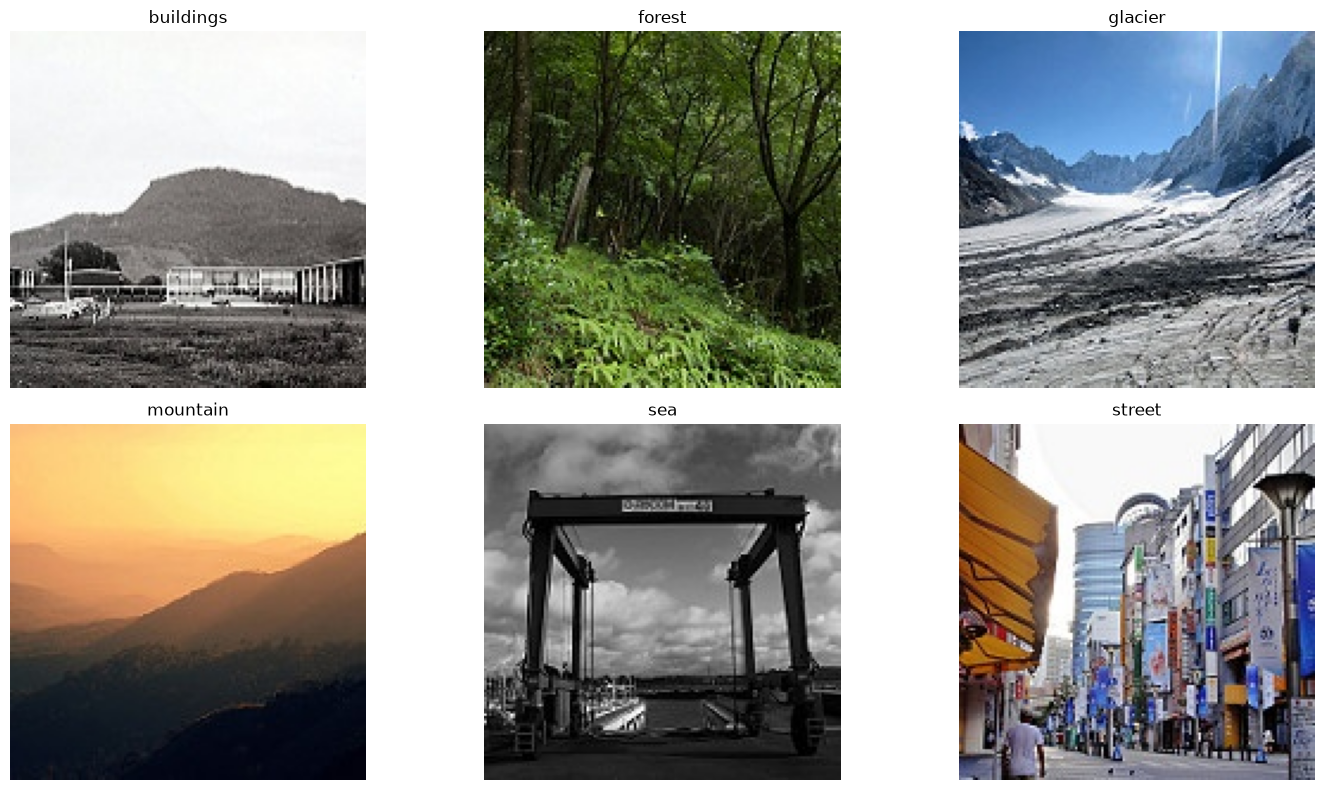

In [11]:
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    number_of_images = len(os.listdir(class_path))
    
    print(class_name, ":", number_of_images)

buildings : 2191
forest : 2271
glacier : 2404
mountain : 2512
sea : 2274
street : 2382


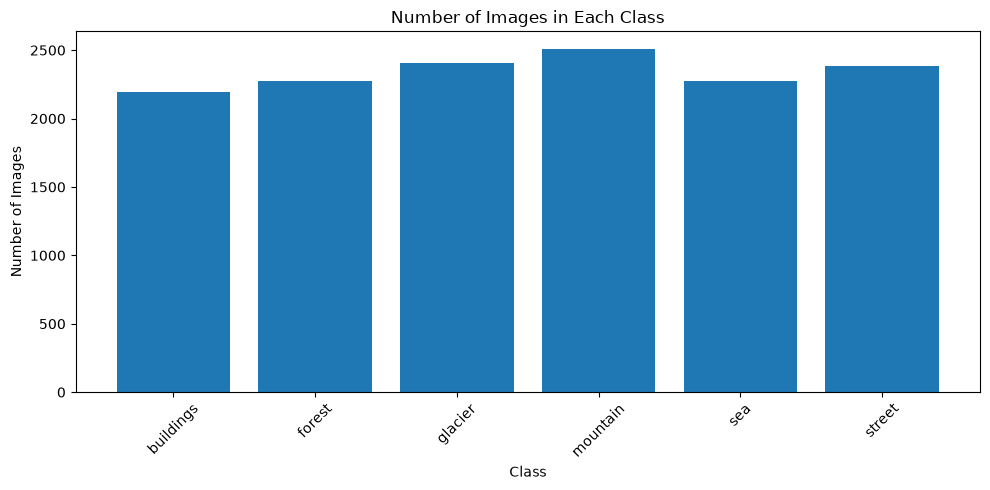

In [13]:
image_counts = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(10, 5))

plt.bar(class_names, image_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Number of Images in Each Class")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

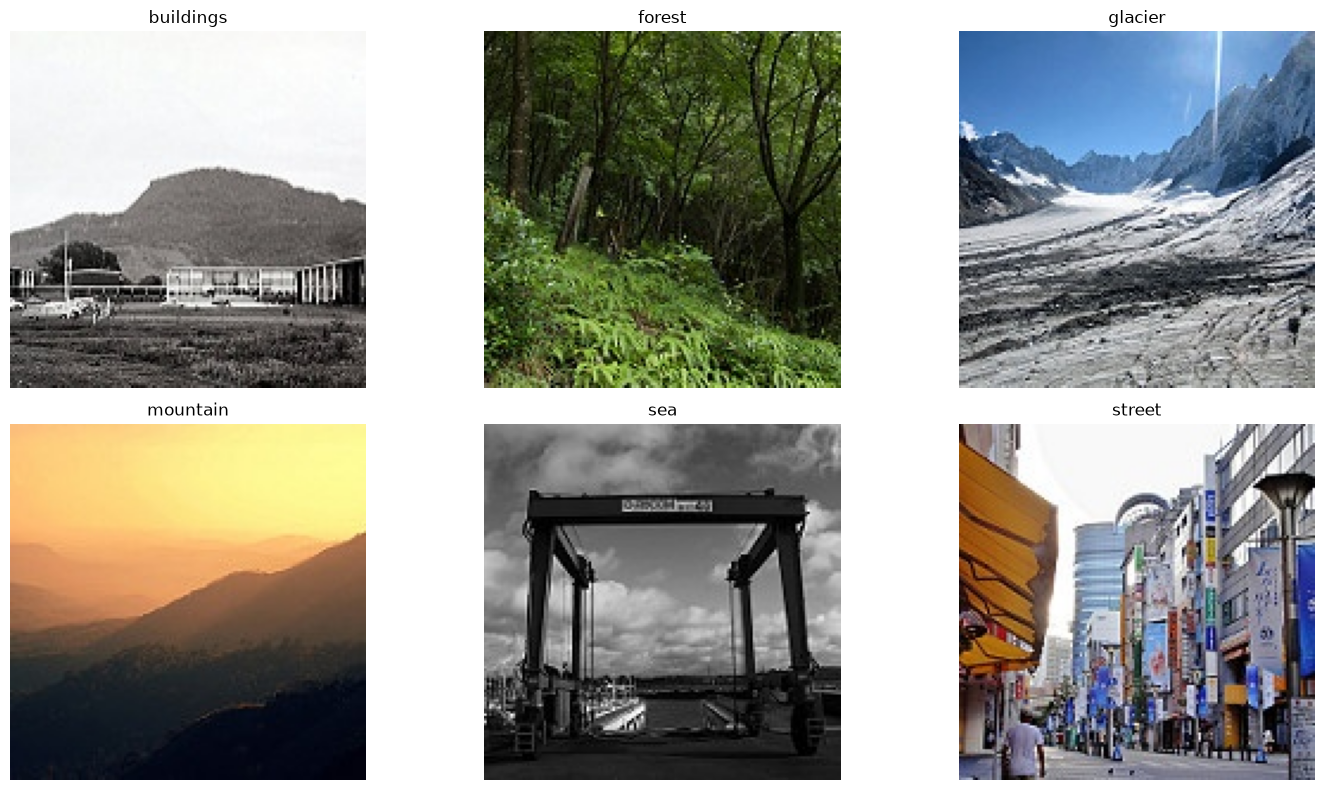

In [14]:
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
image_counts = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    number_of_images = len(os.listdir(class_path))
    
    image_counts.append(number_of_images)
    
    print(class_name, ":", number_of_images)

buildings : 2191
forest : 2271
glacier : 2404
mountain : 2512
sea : 2274
street : 2382


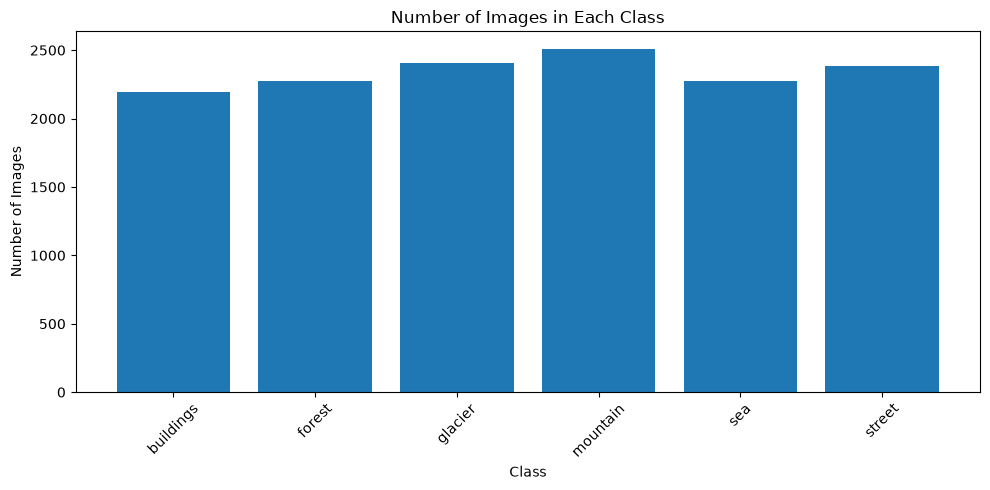

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(class_names, image_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Number of Images in Each Class")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
test_path = r"C:\Users\Alobiedy\Desktop\Intel Image Classification\seg_test"

print(os.listdir(test_path))

['seg_test']


In [18]:
test_dir = r"C:\Users\Alobiedy\Desktop\Intel Image Classification\seg_test\seg_test"

print(os.listdir(test_dir))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [19]:
test_image_counts = []

for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    number_of_images = len(os.listdir(class_path))
    
    test_image_counts.append(number_of_images)
    
    print(class_name, ":", number_of_images)

print("Total test images:", sum(test_image_counts))

buildings : 437
forest : 474
glacier : 553
mountain : 525
sea : 510
street : 501
Total test images: 3000


In [20]:
import tensorflow as tf

img_size = (180, 180)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=42
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [21]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [22]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [23]:
print("Class names:")
print(train_dataset.class_names)

Class names:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [24]:
print(train_dataset.class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [25]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 180, 180, 3)
Labels shape: (32,)


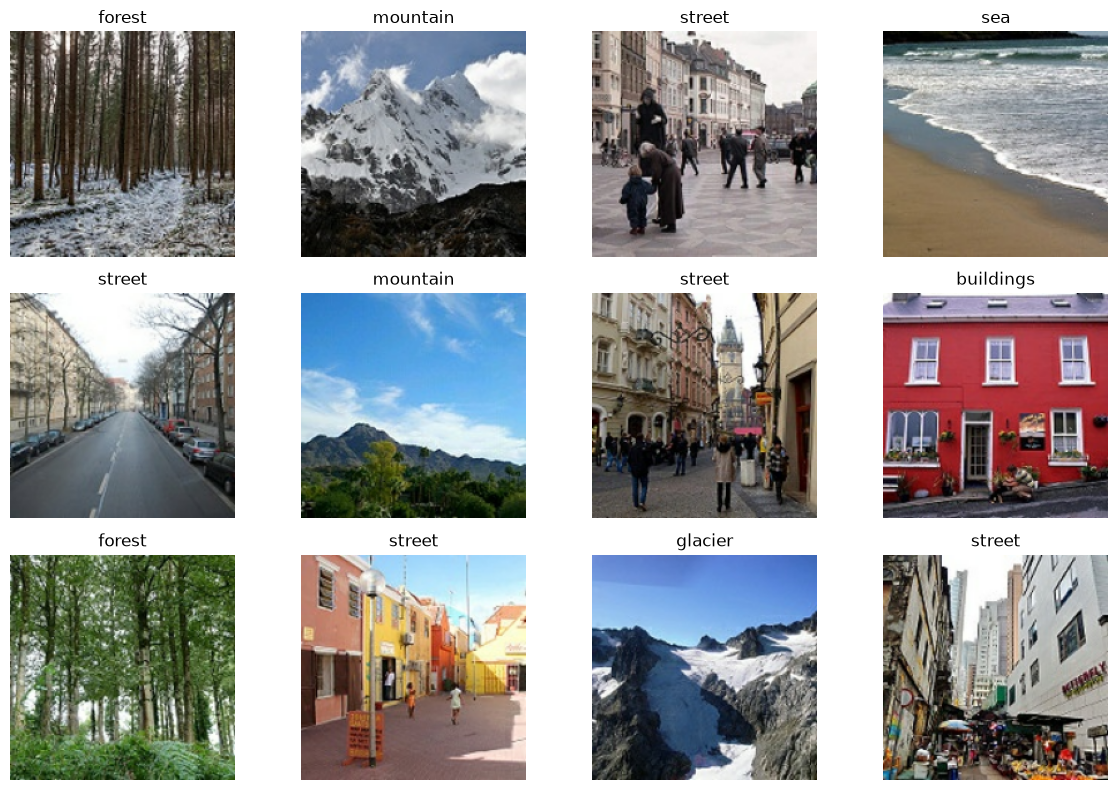

In [26]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

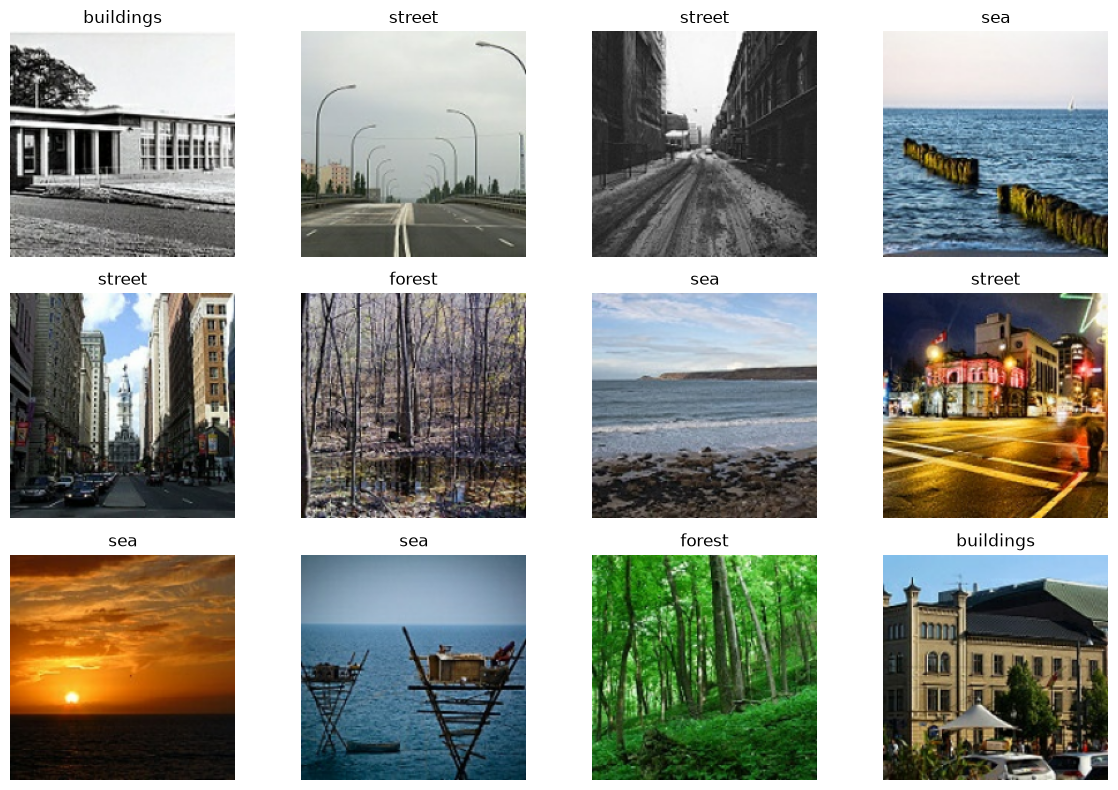

In [27]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

normalized_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [29]:
for images, labels in normalized_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [30]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(180, 180, 3)),
    
    # Normalization
    tf.keras.layers.Rescaling(1./255),
    
    # Convolution Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Convolution Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Convolution Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Convolution Block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 89, 89, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 41, 41, 128)       

In [31]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 89, 89, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 41, 41, 128)       7

In [32]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 89, 89, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 41, 41, 128)       7

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [34]:
print("Model compiled successfully!")

Model compiled successfully!


In [35]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_baseline_cnn.keras",
    monitor="val_loss", 
    save_best_only=True,
    mode="min"
)

In [36]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[checkpoint]
)

Epoch 1/30


351/351 [==============================] - 139s 394ms/step - loss: 1.1518 - accuracy: 0.5466 - val_loss: 0.8678 - val_accuracy: 0.6522
Epoch 2/30
351/351 [==============================] - 144s 409ms/step - loss: 0.8245 - accuracy: 0.6905 - val_loss: 0.7365 - val_accuracy: 0.7256
Epoch 3/30
351/351 [==============================] - 178s 507ms/step - loss: 0.6767 - accuracy: 0.7508 - val_loss: 0.7422 - val_accuracy: 0.7306
Epoch 4/30
351/351 [==============================] - 207s 588ms/step - loss: 0.5727 - accuracy: 0.7930 - val_loss: 0.5379 - val_accuracy: 0.8118
Epoch 5/30
351/351 [==============================] - 176s 501ms/step - loss: 0.4920 - accuracy: 0.8242 - val_loss: 0.6560 - val_accuracy: 0.7712
Epoch 6/30
351/351 [==============================] - 175s 497ms/step - loss: 0.4196 - accuracy: 0.8539 - val_loss: 0.7104 - val_accuracy: 0.7701
Epoch 7/30
351/351 [==============================] - 173s 493ms/step - loss: 0.3487 - accuracy: 0.8785 - val_loss: 0.5800

In [37]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 [==============================] - 16s 169ms/step - loss: 2.7902 - accuracy: 0.7730
Test Loss: 2.7901859283447266
Test Accuracy: 0.7730000019073486


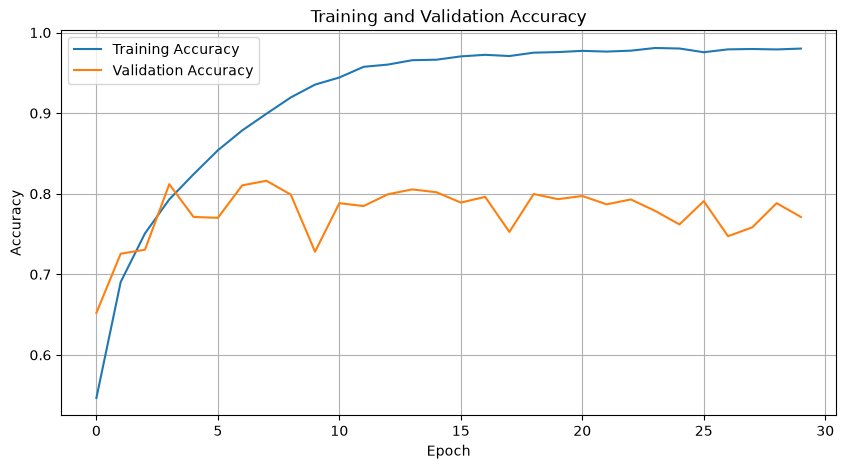

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.grid(True)
plt.show()

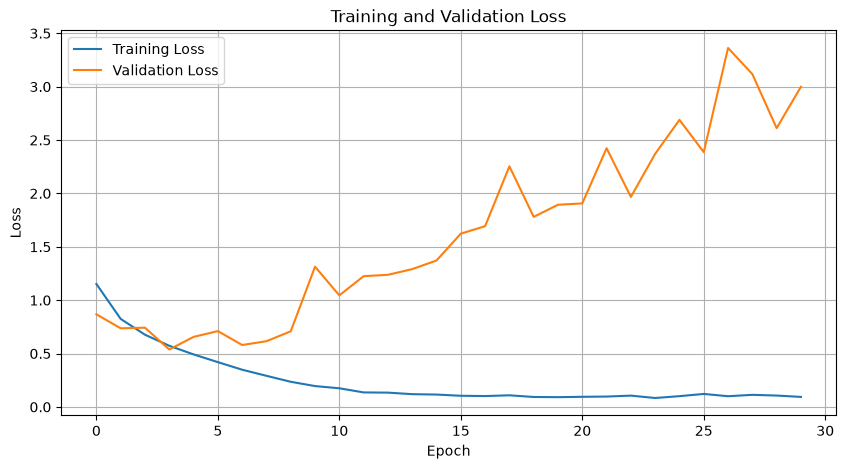

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.grid(True)
plt.show()

In [40]:
model_bn_dropout = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(180, 180, 3)),
    
    # Normalization
    tf.keras.layers.Rescaling(1./255),
    
    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    
    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    
    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.30),
    
    # Block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.30),
    
    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(6, activation='softmax')
])

model_bn_dropout.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_2 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 178, 178, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 89, 89, 32)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 87, 87, 64)       

In [41]:
model_bn_dropout.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [42]:
print("Improved model compiled successfully!")

Improved model compiled successfully!


In [43]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [44]:
checkpoint_bn = tf.keras.callbacks.ModelCheckpoint(
    "best_bn_dropout.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

In [45]:
model_bn_dropout.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Improved model compiled successfully!")

Improved model compiled successfully!


In [46]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_bn = tf.keras.callbacks.ModelCheckpoint(
    "best_bn_dropout.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [47]:
history_bn = model_bn_dropout.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stopping, checkpoint_bn]
)

Epoch 1/30
351/351 [==============================] - 205s 580ms/step - loss: 3.3571 - accuracy: 0.5430 - val_loss: 12.0095 - val_accuracy: 0.1864
Epoch 2/30
351/351 [==============================] - 203s 579ms/step - loss: 1.6984 - accuracy: 0.6705 - val_loss: 4.1683 - val_accuracy: 0.4619
Epoch 3/30
351/351 [==============================] - 201s 572ms/step - loss: 1.3301 - accuracy: 0.7244 - val_loss: 1.7451 - val_accuracy: 0.5752
Epoch 4/30
351/351 [==============================] - 199s 566ms/step - loss: 1.1611 - accuracy: 0.7556 - val_loss: 2.8997 - val_accuracy: 0.5870
Epoch 5/30
351/351 [==============================] - 201s 574ms/step - loss: 1.1052 - accuracy: 0.7762 - val_loss: 1.6581 - val_accuracy: 0.6230
Epoch 6/30
351/351 [==============================] - 202s 574ms/step - loss: 0.9107 - accuracy: 0.7936 - val_loss: 6.3251 - val_accuracy: 0.4305
Epoch 7/30
351/351 [==============================] - 202s 574ms/step - loss: 0.8991 - accuracy: 0.8123 - val_loss: 1.6552 

In [48]:
test_loss_bn, test_accuracy_bn = model_bn_dropout.evaluate(test_dataset)

print("Test Loss:", test_loss_bn)
print("Test Accuracy:", test_accuracy_bn)

94/94 [==============================] - 17s 180ms/step - loss: 0.7099 - accuracy: 0.8270
Test Loss: 0.7099449634552002
Test Accuracy: 0.8270000219345093


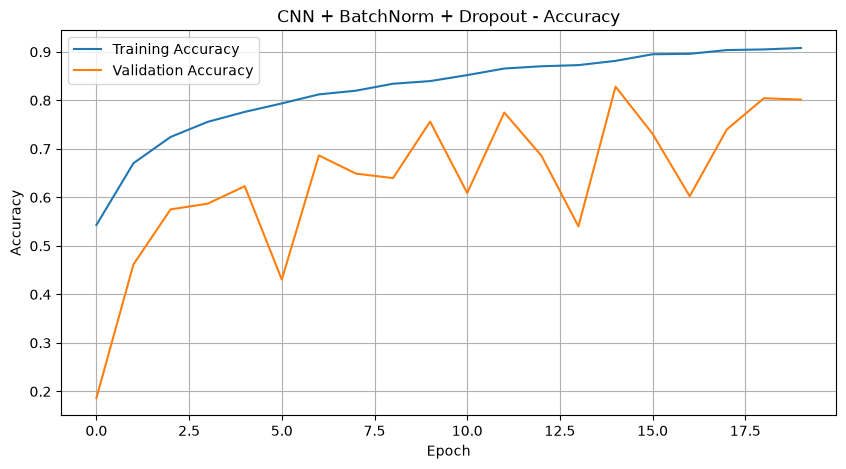

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(history_bn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bn.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN + BatchNorm + Dropout - Accuracy')

plt.legend()
plt.grid(True)
plt.show()

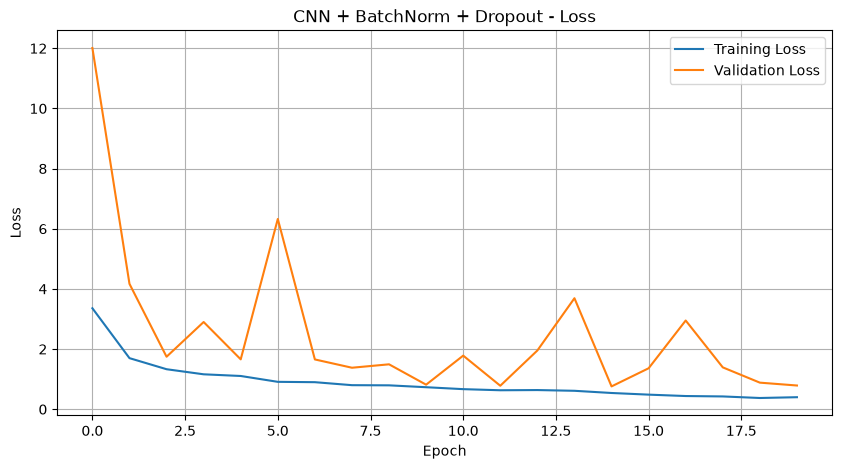

In [50]:
plt.figure(figsize=(10, 5))

plt.plot(history_bn.history['loss'], label='Training Loss')
plt.plot(history_bn.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN + BatchNorm + Dropout - Loss')

plt.legend()
plt.grid(True)
plt.show()

In [51]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


In [52]:
model_augmented = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(180, 180, 3)),
    
    # Data Augmentation
    data_augmentation,
    
    # Normalization
    tf.keras.layers.Rescaling(1./255),
    
    # Convolution Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Convolution Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Convolution Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Convolution Block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(6, activation='softmax')
])

model_augmented.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_3 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_8 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                 

In [53]:
model_augmented.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Augmented model compiled successfully!")

Augmented model compiled successfully!


In [54]:
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_aug = tf.keras.callbacks.ModelCheckpoint(
    "best_augmented_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [55]:
history_aug = model_augmented.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stopping_aug, checkpoint_aug]
)

Epoch 1/30
351/351 [==============================] - 184s 521ms/step - loss: 1.2178 - accuracy: 0.5276 - val_loss: 0.9923 - val_accuracy: 0.6329
Epoch 2/30
351/351 [==============================] - 206s 587ms/step - loss: 0.9193 - accuracy: 0.6559 - val_loss: 0.7050 - val_accuracy: 0.7427
Epoch 3/30
351/351 [==============================] - 210s 599ms/step - loss: 0.8009 - accuracy: 0.7056 - val_loss: 0.6439 - val_accuracy: 0.7616
Epoch 4/30
351/351 [==============================] - 213s 607ms/step - loss: 0.7205 - accuracy: 0.7396 - val_loss: 0.6174 - val_accuracy: 0.7751
Epoch 5/30
351/351 [==============================] - 192s 547ms/step - loss: 0.6761 - accuracy: 0.7589 - val_loss: 0.7631 - val_accuracy: 0.7363
Epoch 6/30
351/351 [==============================] - 190s 542ms/step - loss: 0.6298 - accuracy: 0.7713 - val_loss: 0.5605 - val_accuracy: 0.7969
Epoch 7/30
351/351 [==============================] - 194s 554ms/step - loss: 0.5976 - accuracy: 0.7804 - val_loss: 0.5052 -

In [56]:
test_loss_aug, test_accuracy_aug = model_augmented.evaluate(test_dataset)

print("Test Loss:", test_loss_aug)
print("Test Accuracy:", test_accuracy_aug)

94/94 [==============================] - 15s 157ms/step - loss: 0.5216 - accuracy: 0.8320
Test Loss: 0.5216026306152344
Test Accuracy: 0.8320000171661377


In [57]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model_augmented.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

True labels: (3000,)
Predicted labels: (3000,)


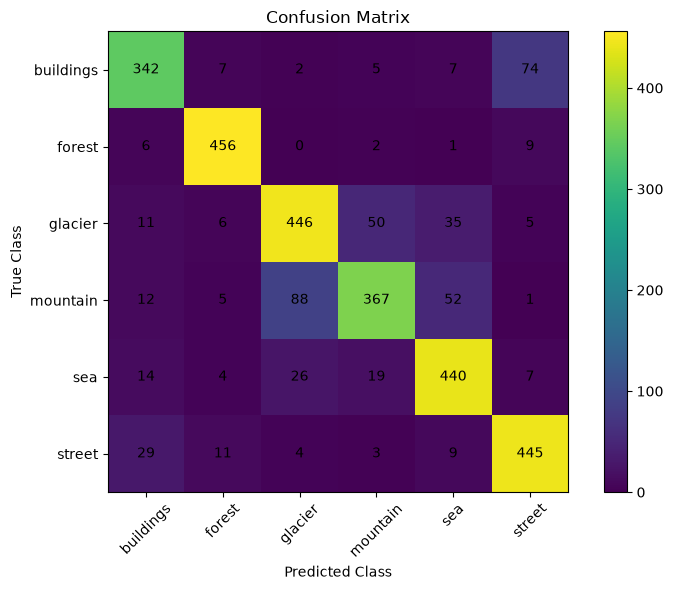

In [58]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

In [59]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

   buildings       0.83      0.78      0.80       437
      forest       0.93      0.96      0.95       474
     glacier       0.79      0.81      0.80       553
    mountain       0.82      0.70      0.76       525
         sea       0.81      0.86      0.83       510
      street       0.82      0.89      0.85       501

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



In [60]:
from tensorflow.keras.applications import VGG16

vgg16_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)

print("VGG16 loaded successfully!")

VGG16 loaded successfully!


In [61]:
for layer in vgg16_base.layers:
    layer.trainable = False

print("VGG16 layers frozen:", len(vgg16_base.layers))

VGG16 layers frozen: 19


In [62]:
model_vgg16 = tf.keras.Sequential([
    
    vgg16_base,
    
    tf.keras.layers.GlobalAveragePooling2D(),
    
    tf.keras.layers.Dense(128, activation='relu'),
    
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(6, activation='softmax')
])

model_vgg16.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 5, 5, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense_3 (Dense)             (None, 128)               65664     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 6)                 774       
                                                                 
Total params: 14781126 (56.39 MB)
Trainable params: 66438 (259.52 KB)
Non-trainable params: 14714688 (56.13 MB)
________

In [63]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_vgg = train_dataset.map(
    lambda images, labels: (preprocess_input(tf.cast(images, tf.float32)), labels)
)

validation_vgg = validation_dataset.map(
    lambda images, labels: (preprocess_input(tf.cast(images, tf.float32)), labels)
)

test_vgg = test_dataset.map(
    lambda images, labels: (preprocess_input(tf.cast(images, tf.float32)), labels)
)

print("VGG16 datasets prepared successfully!")

VGG16 datasets prepared successfully!


In [64]:
model_vgg16.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("VGG16 model compiled successfully!")

VGG16 model compiled successfully!


In [65]:
early_stopping_vgg = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_vgg = tf.keras.callbacks.ModelCheckpoint(
    "best_vgg16.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

print("VGG16 callbacks created successfully!")

VGG16 callbacks created successfully!


In [66]:
history_vgg = model_vgg16.fit(
    train_vgg,
    validation_data=validation_vgg,
    epochs=20,
    callbacks=[early_stopping_vgg, checkpoint_vgg]
)

Epoch 1/20
351/351 [==============================] - 1224s 3s/step - loss: 2.3883 - accuracy: 0.5733 - val_loss: 0.4621 - val_accuracy: 0.8607
Epoch 2/20
351/351 [==============================] - 997s 3s/step - loss: 0.8455 - accuracy: 0.7838 - val_loss: 0.3489 - val_accuracy: 0.8988
Epoch 3/20
351/351 [==============================] - 931s 3s/step - loss: 0.5727 - accuracy: 0.8401 - val_loss: 0.3064 - val_accuracy: 0.9073
Epoch 4/20
351/351 [==============================] - 942s 3s/step - loss: 0.4622 - accuracy: 0.8614 - val_loss: 0.2894 - val_accuracy: 0.9109
Epoch 5/20
351/351 [==============================] - 937s 3s/step - loss: 0.4115 - accuracy: 0.8756 - val_loss: 0.2823 - val_accuracy: 0.9173
Epoch 6/20
351/351 [==============================] - 963s 3s/step - loss: 0.3748 - accuracy: 0.8824 - val_loss: 0.2753 - val_accuracy: 0.9159
Epoch 7/20
351/351 [==============================] - 930s 3s/step - loss: 0.3515 - accuracy: 0.8878 - val_loss: 0.2739 - val_accuracy: 0.919

In [67]:
test_loss_vgg, test_accuracy_vgg = model_vgg16.evaluate(test_vgg)

print("VGG16 Test Loss:", test_loss_vgg)
print("VGG16 Test Accuracy:", test_accuracy_vgg)

94/94 [==============================] - 179s 2s/step - loss: 0.2750 - accuracy: 0.9173
VGG16 Test Loss: 0.275028795003891
VGG16 Test Accuracy: 0.9173333048820496


In [69]:
y_true_vgg = []
y_pred_vgg = []

for images, labels in test_vgg:
    predictions = model_vgg16.predict(images, verbose=0)

    y_true_vgg.extend(labels.numpy())
    y_pred_vgg.extend(np.argmax(predictions, axis=1))

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

print("True labels:", y_true_vgg.shape)
print("Predicted labels:", y_pred_vgg.shape)

True labels: (3000,)
Predicted labels: (3000,)


In [70]:
from sklearn.metrics import classification_report

report_vgg = classification_report(
    y_true_vgg,
    y_pred_vgg,
    target_names=class_names
)

print(report_vgg)

              precision    recall  f1-score   support

   buildings       0.92      0.90      0.91       437
      forest       0.99      1.00      0.99       474
     glacier       0.88      0.83      0.85       553
    mountain       0.86      0.88      0.87       525
         sea       0.95      0.97      0.96       510
      street       0.92      0.93      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



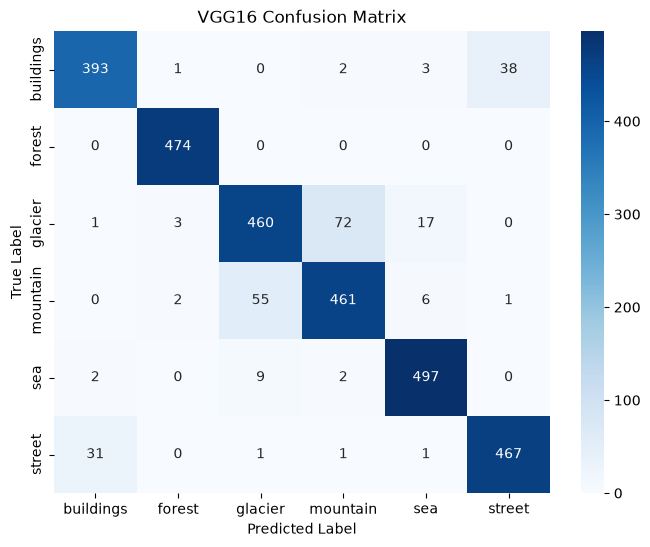

In [71]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_vgg,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("VGG16 Confusion Matrix")
plt.show()

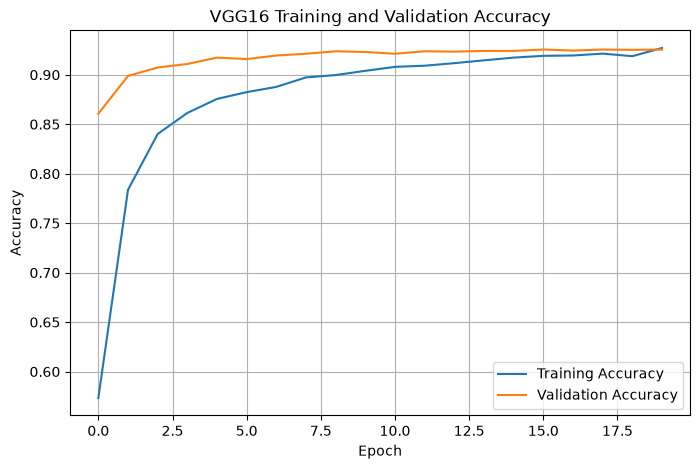

In [72]:
plt.figure(figsize=(8, 5))

plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG16 Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

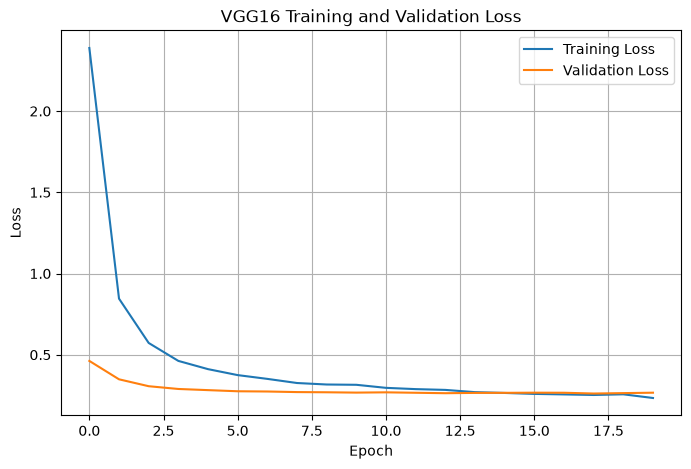

In [73]:
plt.figure(figsize=(8, 5))

plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG16 Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


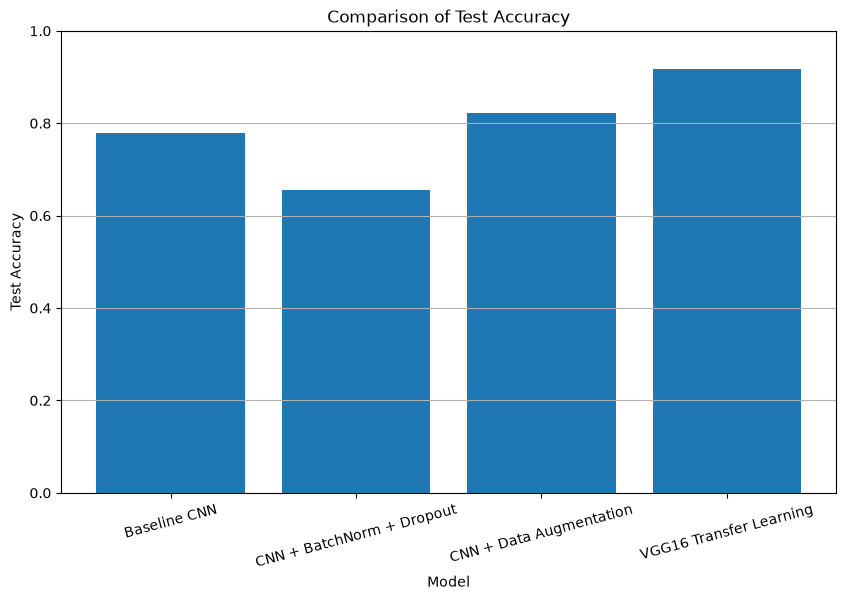

In [74]:
models = [
    'Baseline CNN',
    'CNN + BatchNorm + Dropout',
    'CNN + Data Augmentation',
    'VGG16 Transfer Learning'
]

accuracies = [
    0.7790,
    0.6547,
    0.8213,
    0.9173
]

plt.figure(figsize=(10, 6))

plt.bar(models, accuracies)

plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.title('Comparison of Test Accuracy')

plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.grid(axis='y')

plt.show()

In [77]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Baseline CNN',
        'CNN + BatchNorm + Dropout',
        'CNN + Data Augmentation',
        'VGG16 Transfer Learning'
    ],
    'Test Accuracy': [
        0.7790,
        0.6547,
        0.8213,
        0.9173
    ],
    'Test Loss': [
        2.5134,
        1.0080,
        0.5111,
        0.2750
    ]
})

results['Test Accuracy (%)'] = results['Test Accuracy'] * 100

results

,Model,Test Accuracy,Test Loss,Test Accuracy (%)
0,Baseline CNN,0.7790,2.5134,77.90
1,CNN + BatchNorm + Dropout,0.6547,1.0080,65.47
2,CNN + Data Augmentation,0.8213,0.5111,82.13
3,VGG16 Transfer Learning,0.9173,0.2750,91.73


أدخل مسار الصورة: "C:\Users\Alobiedy\Desktop\Intel Image Classification\seg_test\seg_test\glacier\20204.jpg"

المسار الذي أدخلته:
C:\Users\Alobiedy\Desktop\Intel Image Classification\seg_test\seg_test\glacier\20204.jpg

✅ تم العثور على الصورة.

   Prediction Probabilities
buildings: 0.00%
forest: 0.00%
glacier: 78.39%
mountain: 21.60%
sea: 0.00%
street: 0.00%

       Prediction Result
Predicted Class: glacier
Confidence: 78.39%
Model Accuracy: 91.73%


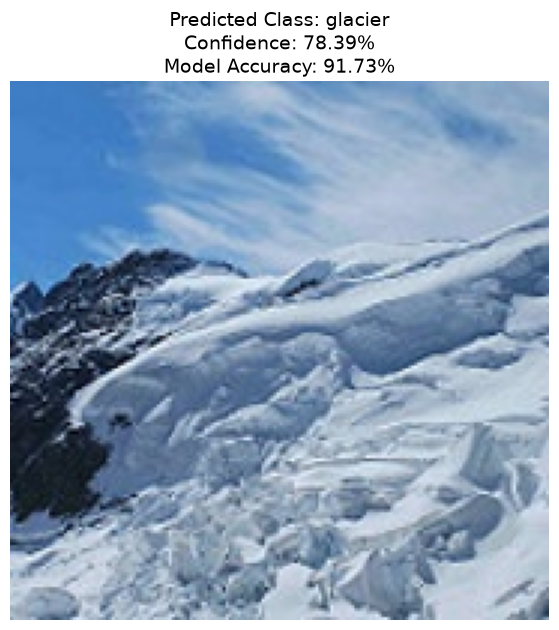

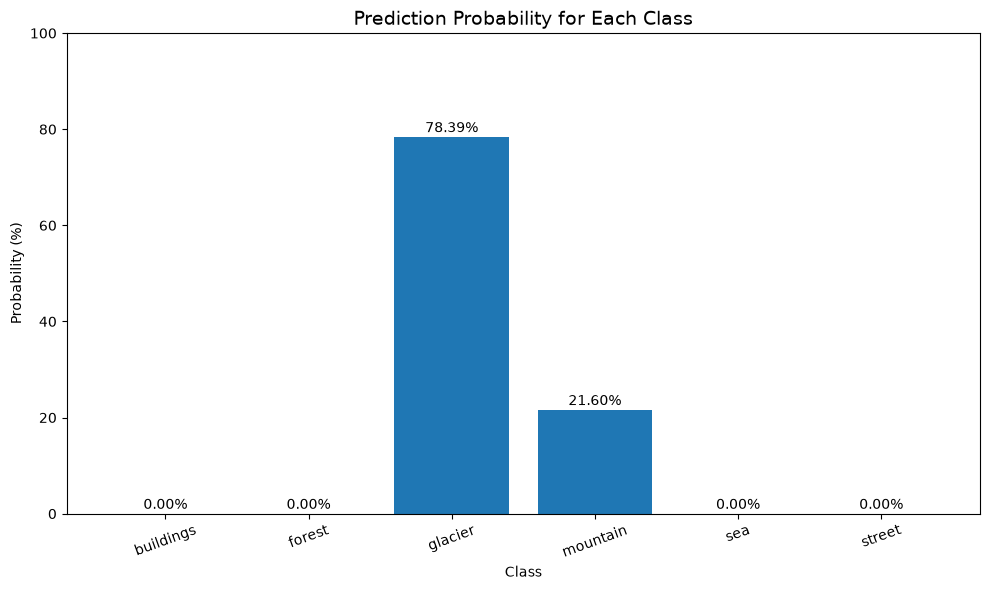

In [32]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import os
from PIL import Image

# ==========================================
# دقة النموذج على بيانات الاختبار
# ==========================================

model_accuracy = 91.73


# ==========================================
# طلب مسار الصورة من المستخدم
# ==========================================

image_path = input("أدخل مسار الصورة: ").strip()

# إزالة علامات الاقتباس إذا كانت موجودة
image_path = image_path.strip('"').strip("'")


print("\nالمسار الذي أدخلته:")
print(image_path)


# ==========================================
# التأكد من وجود الصورة
# ==========================================

if not os.path.isfile(image_path):

    print("\n❌ خطأ: مسار الصورة غير صحيح.")
    print("تأكد من كتابة المسار كاملًا.")

else:

    print("\n✅ تم العثور على الصورة.")


    # ==========================================
    # تحميل الصورة
    # ==========================================

    img = Image.open(image_path).convert("RGB")

    # تغيير حجم الصورة
    img = img.resize((180, 180))


    # ==========================================
    # تحويل الصورة إلى Array
    # ==========================================

    img_array = np.array(img, dtype=np.float32)


    # ==========================================
    # تجهيز الصورة لـ VGG16
    # ==========================================

    img_preprocessed = tf.keras.applications.vgg16.preprocess_input(
        img_array
    )


    # ==========================================
    # إضافة Batch Dimension
    # ==========================================

    img_batch = np.expand_dims(
        img_preprocessed,
        axis=0
    )


    # ==========================================
    # التنبؤ
    # ==========================================

    prediction = model_vgg16.predict(
        img_batch,
        verbose=0
    )


    # ==========================================
    # حساب الاحتمالات
    # ==========================================

    probabilities = prediction[0] * 100


    # ==========================================
    # الحصول على الفئة الأعلى
    # ==========================================

    predicted_index = np.argmax(prediction[0])

    predicted_class = class_names[predicted_index]

    confidence = probabilities[predicted_index]


    # ==========================================
    # طباعة احتمالات جميع الفئات
    # ==========================================

    print("\n==============================")
    print("   Prediction Probabilities")
    print("==============================")

    for i, class_name in enumerate(class_names):

        print(
            f"{class_name}: {probabilities[i]:.2f}%"
        )


    # ==========================================
    # طباعة النتيجة النهائية
    # ==========================================

    print("\n==============================")
    print("       Prediction Result")
    print("==============================")

    print(
        "Predicted Class:",
        predicted_class
    )

    print(
        "Confidence:",
        f"{confidence:.2f}%"
    )

    print(
        "Model Accuracy:",
        f"{model_accuracy:.2f}%"
    )


    # ==========================================
    # عرض الصورة
    # ==========================================

    plt.figure(figsize=(7, 7))

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"Predicted Class: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%\n"
        f"Model Accuracy: {model_accuracy:.2f}%",
        fontsize=14
    )

    plt.show()


    # ==========================================
    # رسم احتمالات جميع الفئات
    # ==========================================

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        class_names,
        probabilities
    )

    plt.title(
        "Prediction Probability for Each Class",
        fontsize=14
    )

    plt.xlabel("Class")

    plt.ylabel("Probability (%)")

    plt.ylim(0, 100)

    plt.xticks(rotation=20)

    # كتابة النسبة فوق كل عمود
    for bar, probability in zip(
        bars,
        probabilities
    ):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{probability:.2f}%",
            ha="center",
            fontsize=10
        )

    plt.tight_layout()

    plt.show()

In [78]:
best_model = results.loc[results['Test Accuracy'].idxmax()]

print("Best Model:", best_model['Model'])
print("Test Accuracy:", f"{best_model['Test Accuracy (%)']:.2f}%")
print("Test Loss:", f"{best_model['Test Loss']:.4f}")

Best Model: VGG16 Transfer Learning
Test Accuracy: 91.73%
Test Loss: 0.2750


In [80]:
import pandas as pd

results_clean = pd.DataFrame({
    'Model': [
        'Baseline CNN',
        'CNN + BatchNorm + Dropout',
        'CNN + Data Augmentation',
        'VGG16 Transfer Learning'
    ],
    'Test Accuracy (%)': [
        77.90,
        65.47,
        82.13,
        91.73
    ],
    'Test Loss': [
        2.5134,
        1.0080,
        0.5111,
        0.2750
    ]
})

results_clean

,Model,Test Accuracy (%),Test Loss
0,Baseline CNN,77.90,2.5134
1,CNN + BatchNorm + Dropout,65.47,1.0080
2,CNN + Data Augmentation,82.13,0.5111
3,VGG16 Transfer Learning,91.73,0.2750


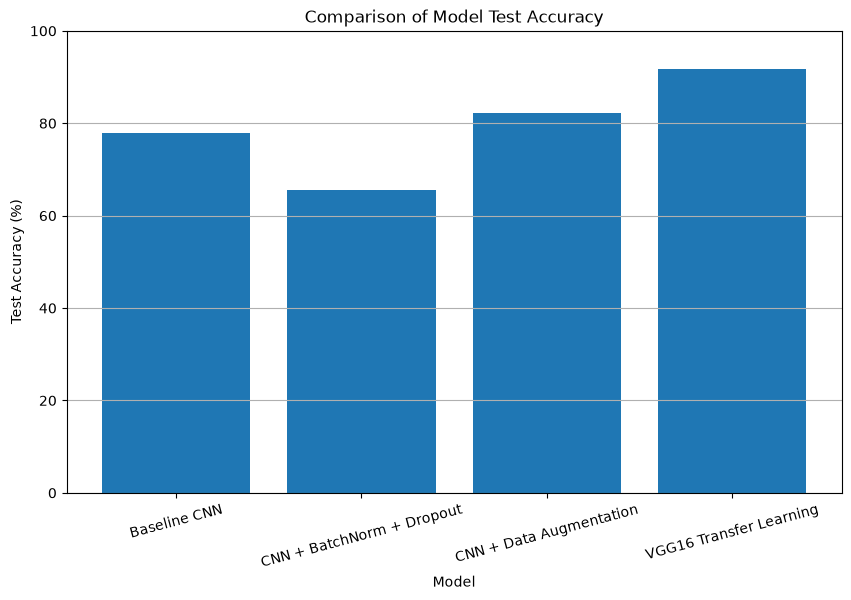

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    results_clean['Model'],
    results_clean['Test Accuracy (%)']
)

plt.ylabel('Test Accuracy (%)')
plt.xlabel('Model')
plt.title('Comparison of Model Test Accuracy')

plt.ylim(0, 100)
plt.xticks(rotation=15)

plt.grid(axis='y')
plt.show()

In [82]:
import pandas as pd

final_results = pd.DataFrame({
    'Model': [
        'Baseline CNN',
        'CNN + BatchNorm + Dropout',
        'CNN + Data Augmentation',
        'VGG16 Transfer Learning'
    ],
    'Test Accuracy (%)': [
        77.90,
        65.47,
        82.13,
        91.73
    ],
    'Test Loss': [
        2.5134,
        1.0080,
        0.5111,
        0.2750
    ]
})

final_results

,Model,Test Accuracy (%),Test Loss
0,Baseline CNN,77.90,2.5134
1,CNN + BatchNorm + Dropout,65.47,1.0080
2,CNN + Data Augmentation,82.13,0.5111
3,VGG16 Transfer Learning,91.73,0.2750


# Conclusion

This project focused on image classification using the Intel Image Classification dataset.

The dataset contains six classes:
- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

Several deep learning models were implemented and evaluated, including a Baseline CNN, CNN with Batch Normalization and Dropout, CNN with Data Augmentation, and VGG16 using Transfer Learning.

The experimental results showed that VGG16 Transfer Learning achieved the best performance, with a Test Accuracy of 91.73% and a Test Loss of 0.2750.

The Classification Report showed strong performance across the six classes. The Forest class achieved the highest F1-score of 0.99, while the Glacier class had the lowest F1-score of 0.85.

Overall, VGG16 Transfer Learning was the best-performing model for this image classification task.

# Limitations and Future Work

Although the VGG16 model achieved a high test accuracy of 91.73%, some classification errors remained.

The main classification difficulties were related to visually similar natural scenes, especially Glacier and Mountain.

Future improvements could include:
- Using a larger and more diverse dataset.
- Applying additional data augmentation techniques.
- Fine-tuning the pretrained VGG16 layers.
- Testing other pretrained deep learning architectures.
- Evaluating the model on more real-world images.

# Final Results

The final comparison shows that VGG16 Transfer Learning achieved the highest test accuracy.

**Best Model:** VGG16 Transfer Learning

**Test Accuracy:** 91.73%

**Test Loss:** 0.2750

Therefore, VGG16 Transfer Learning was selected as the final model for the project.